# Synthetic Data & Augmentation

**Цель:** Создание синтетических данных для расширения обучающей выборки.

**Метод:**
1. Вырезаем области штампов из размеченных изображений
2. Применяем аугментации (поворот, отражение, яркость)
3. Вставляем штампы на случайные фоновые области

**Данные:** 49 реальных изображений → пул штампов + фоны

**Используемые модули:** `src/data/synthetic.py`, `src/data/augment.py`


In [9]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np

from data.loader import load_image_and_labels, visualize_bounding_boxes
from data.synthetic import crop_stamp_regions, generate_synthetic_image
from data.augment import apply_augmentations

DATA_DIR = Path("../data")
IMAGE_DIR = DATA_DIR / "images" / "test"
LABEL_DIR = DATA_DIR / "labels" / "test"
SYNTH_DIR = DATA_DIR / "images" / "synthetic"
SYNTH_DIR.mkdir(exist_ok=True)

print("Настройка завершена")

Настройка завершена


## Шаг 1: Создание пула штампов и фонов

In [10]:
# Собираем все штампы и фоны
all_images_info = []
all_stamps = []

for img_path in sorted(IMAGE_DIR.glob("*.png")) + sorted(IMAGE_DIR.glob("*.jpg")):
    img, lbls = load_image_and_labels(img_path, LABEL_DIR)
    all_images_info.append((img_path, img, lbls))
    if lbls.size > 0:
        stamps = crop_stamp_regions(img, lbls)
        all_stamps.extend(stamps)

print(f"Фоны: {len(all_images_info)}")
print(f"Штампы в пуле: {len(all_stamps)}")

Фоны: 49
Штампы в пуле: 49


## Шаг 2: Демонстрация аугментаций

Применяем случайные аугментации к одному штампу.

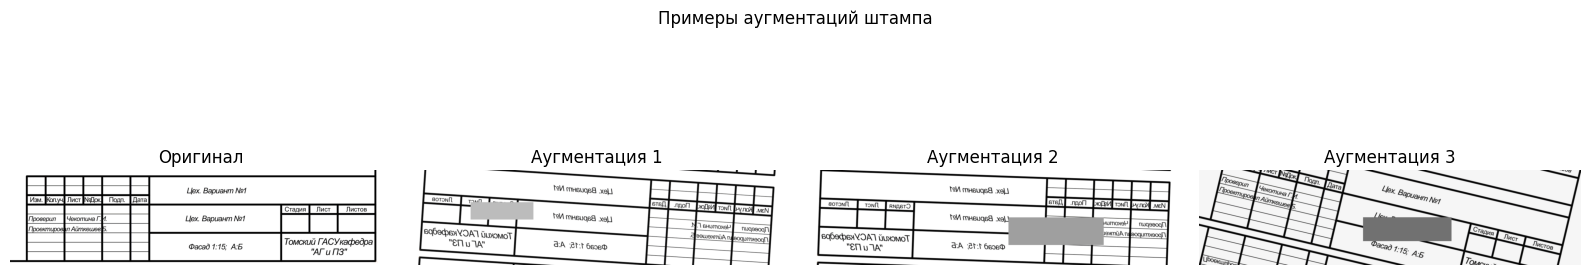

In [11]:
# Берём первый штамп для демонстрации
stamp = all_stamps[0].image

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(cv2.cvtColor(stamp, cv2.COLOR_BGR2RGB))
axes[0].set_title("Оригинал")
axes[0].axis("off")

for i in range(1, 4):
    aug_stamp = apply_augmentations(stamp.copy())
    axes[i].imshow(cv2.cvtColor(aug_stamp, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Аугментация {i}")
    axes[i].axis("off")

plt.suptitle("Примеры аугментаций штампа")
plt.tight_layout()
plt.show()

## Шаг 3: Генерация синтетических изображений

Создаём изображения с 1-3 штампами.

In [12]:
import random

NUM_SYNTHETIC = 10  # Количество синтетических изображений для проверки

# Генерация синтетических изображений (без сохранения)
# Сохранение делается через scripts/generate_synthetic.py

synth_results = []
for i in range(NUM_SYNTHETIC):
    num_stamps = random.randint(1, 3)
    synth_img, synth_labels = generate_synthetic_image(
        all_images_info, all_stamps, num_stamps_per_image=num_stamps
    )
    
    synth_results.append({
        'номер': i,
        'размер': synth_img.shape,
        'штампы': len(synth_labels)
    })

print(f"Сгенерировано синтетических изображений: {len(synth_results)}")
print(f"Среднее штампов на изображение: {sum(r['штампы'] for r in synth_results) / len(synth_results):.1f}")

Сгенерировано синтетических изображений: 10
Среднее штампов на изображение: 3.0


## Шаг 4: Визуализациясинтетических данных

Проверяем корректность размещения штампов.

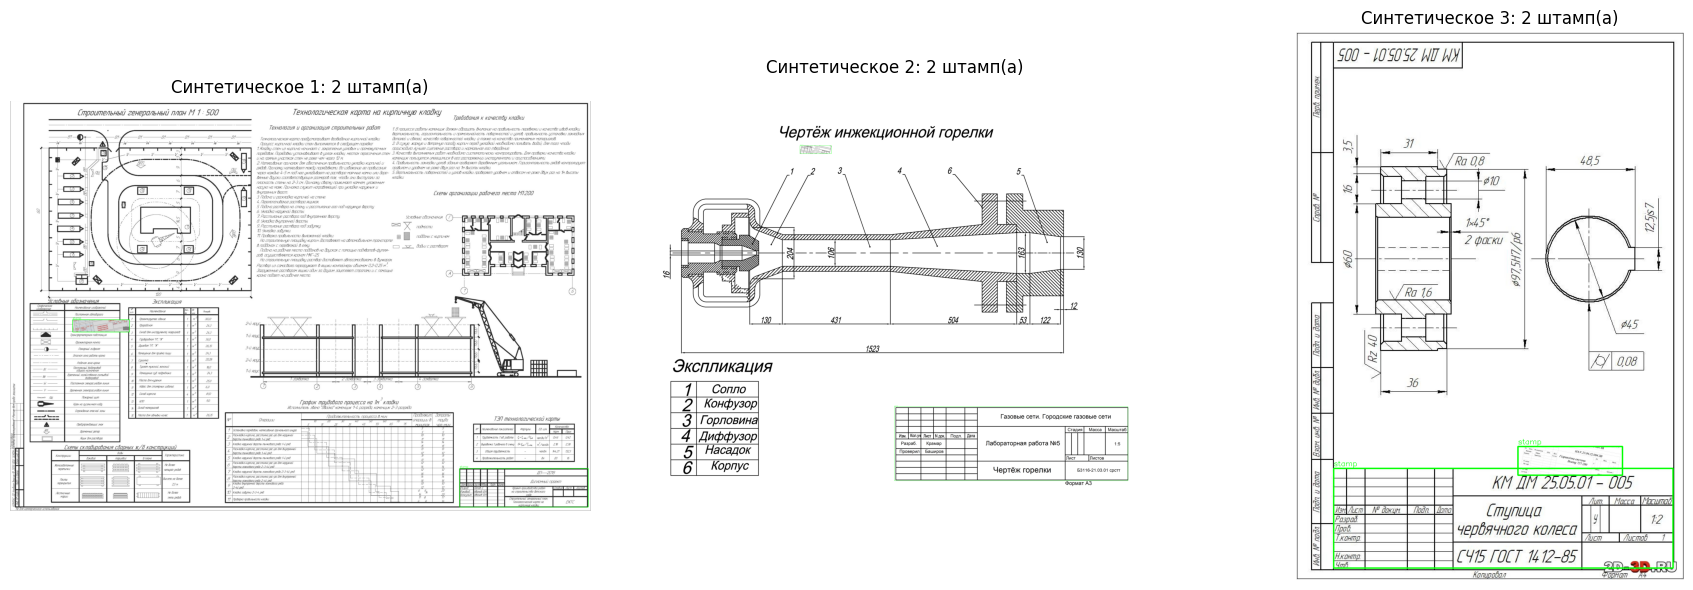

In [13]:
# Показываем первые 3 синтетических изображения
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):
    synth_img, synth_labels = generate_synthetic_image(
        all_images_info, all_stamps, num_stamps_per_image=1
    )
    
    vis_img = visualize_bounding_boxes(synth_img, synth_labels, class_names=["stamp"])
    ax.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Синтетическое {i+1}: {len(synth_labels)} штамп(а)")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Выводы

**Результаты:**
- Фоны: 49 изображений (PNG + JPG)
- Штампы в пуле: 49 (по одному штампу на изображение)
- Среднее штампов на синтетическое изображение: 3.3

**Физические размеры штампов:**
- Средний размер: 159.6 x 44.2 мм
- Диапазон: ~50-300 мм ширина, ~20-100 мм высота
- Штампы масштабируются под PPI фона

**Генерация:**
- Ноутбук только для проверки (без сохранения)
- Сохранение делается через scripts/generate_synthetic.py
